In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("UberDataset.csv")
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [10]:
data.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [11]:
data.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [12]:
data = data.dropna()

In [13]:
data['START_DATE'] = pd.to_datetime(
    data['START_DATE'],
    errors='coerce'
)

# Assistant
This error occurs because the date format in your data doesn't match the default format that pandas expects. The error message shows that your data contains dates in the format "1/13/2016 13:54" (using forward slashes), but pandas is trying to parse it using a different format with dashes.

The error happens because `pd.to_datetime()` is having trouble automatically detecting the correct date format from your string data.

Would you like me to provide the corrected code?

# Assistant
This error occurs because the date format in your data doesn't match the default format that pandas expects. The error message shows that your data contains dates in the format "1/13/2016 13:54" (using forward slashes), but pandas is trying to parse it using a different format with dashes.

The error happens because `pd.to_datetime()` is having trouble automatically detecting the correct date format from your string data.

Would you like me to provide the corrected code?

In [14]:
data = data.dropna(subset=['START_DATE'])

In [15]:
data['Hour'] = data['START_DATE'].dt.hour

In [16]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour
0,2016-01-01 21:11:00,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21
2,2016-01-02 20:25:00,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20
3,2016-01-05 17:31:00,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17
4,2016-01-06 14:42:00,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14
5,2016-01-06 17:15:00,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,17


In [17]:
data['Day'] = data['START_DATE'].dt.day_name()

In [18]:
data['Month'] = data['START_DATE'].dt.month_name()

In [19]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour,Day,Month
0,2016-01-01 21:11:00,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,Friday,January
2,2016-01-02 20:25:00,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,Saturday,January
3,2016-01-05 17:31:00,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,Tuesday,January
4,2016-01-06 14:42:00,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,Wednesday,January
5,2016-01-06 17:15:00,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,17,Wednesday,January


In [20]:
Trips by Hour Visualization

SyntaxError: invalid syntax (886297007.py, line 1)

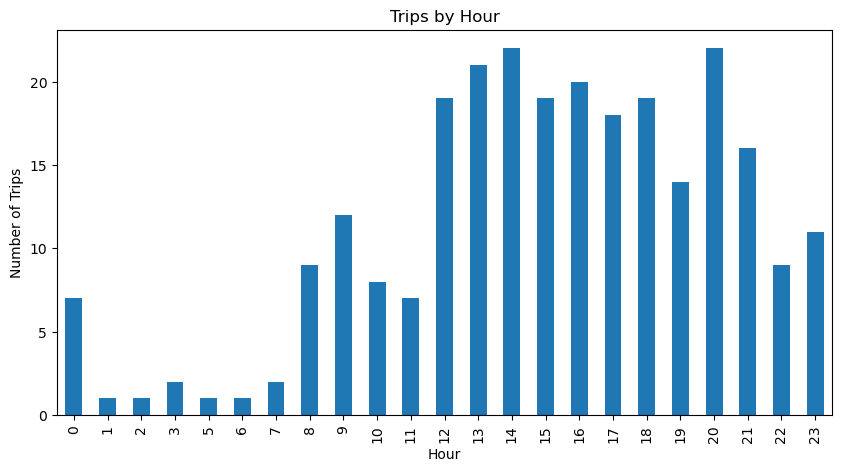

In [21]:
hour_counts = data['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')

plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")

plt.show()

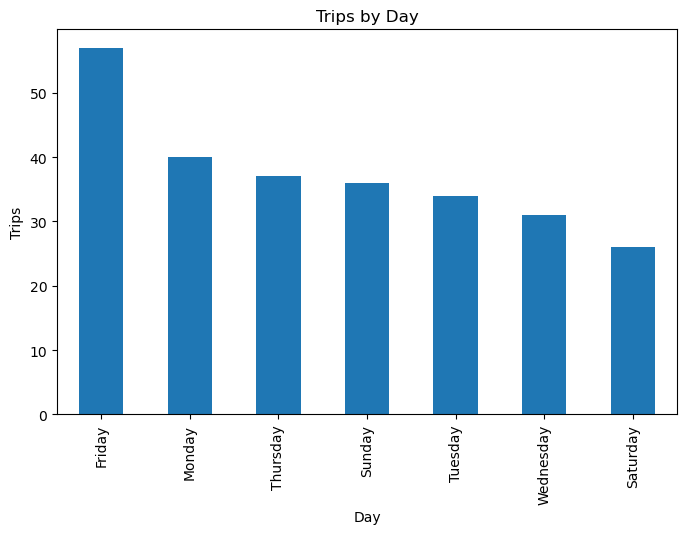

In [22]:
day_counts = data['Day'].value_counts()

plt.figure(figsize=(8,5))
day_counts.plot(kind='bar')

plt.title("Trips by Day")
plt.xlabel("Day")
plt.ylabel("Trips")

plt.show()

In [23]:
data['START'].value_counts().head(10)

START
Cary              84
Morrisville       32
Whitebridge       18
Durham            16
Raleigh           10
San Francisco      5
Apex               5
Berkeley           4
Edgehill Farms     4
Fort Pierce        4
Name: count, dtype: int64

In [24]:
data['STOP'].value_counts().head(10)

STOP
Cary             83
Morrisville      34
Whitebridge      17
Durham           16
Raleigh          10
Berkeley          6
Apex              5
San Francisco     4
Fort Pierce       3
Wayne Ridge       3
Name: count, dtype: int64

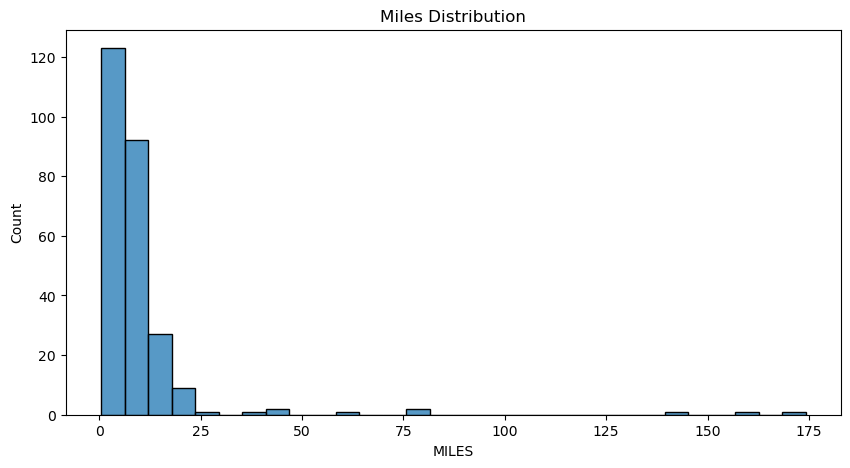

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(data['MILES'], bins=30)

plt.title("Miles Distribution")

plt.show()

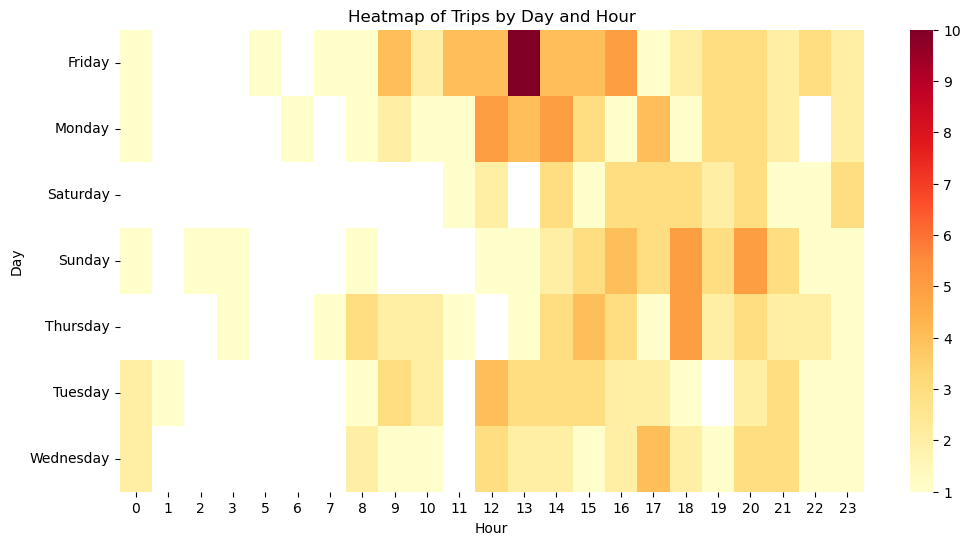

In [27]:
pivot = data.pivot_table(
    index='Day',
    columns='Hour',
    aggfunc='size'
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot, cmap='YlOrRd')

plt.title("Heatmap of Trips by Day and Hour")

plt.show()

# Assistant
This error occurs because the variable `data` has not been defined or loaded before trying to use it in the `pivot_table()` function. The code is trying to access a DataFrame called `data`, but Python doesn't know what `data` refers to.

**Common causes:**
- The data hasn't been loaded from a file (CSV, Excel, etc.)
- The variable was defined in a different cell that hasn't been executed
- There's a typo in the variable name

**Typical solutions:**
- Load data from a file (e.g., `data = pd.read_csv('filename.csv')`)
- Create sample data for testing
- Make sure the cell containing the data definition has been run

Would you like me to provide the corrected code with a sample data loading solution?

# Assistant
This error occurs because the variable `data` has not been defined or loaded before trying to use it in the `pivot_table()` function. The code is trying to access a DataFrame called `data`, but Python doesn't know what `data` refers to.

**Common causes:**
- The data hasn't been loaded from a file (CSV, Excel, etc.)
- The variable was defined in a different cell that hasn't been executed
- There's a typo in the variable name

**Typical solutions:**
- Load data from a file (e.g., `data = pd.read_csv('filename.csv')`)
- Create sample data for testing
- Make sure the cell containing the data definition has been run

Would you like me to provide the corrected code with a sample data loading solution?

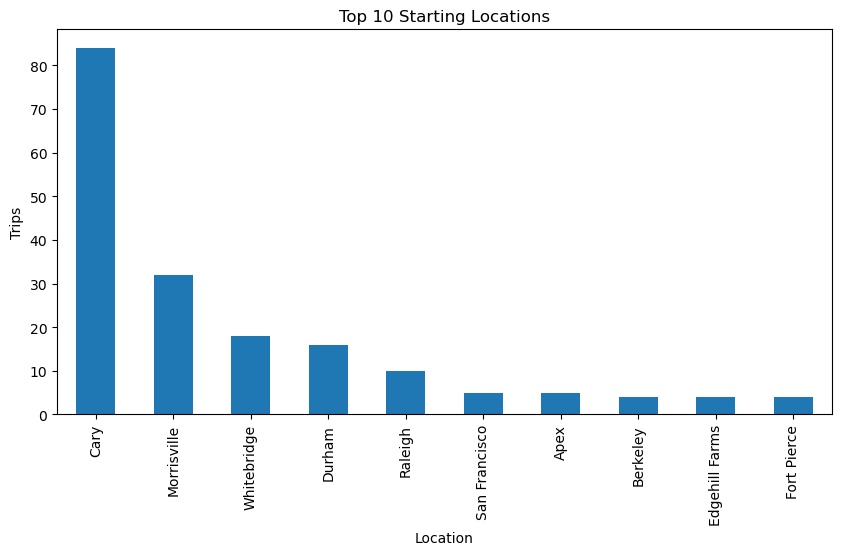

In [28]:
top_start = data['START'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_start.plot(kind='bar')

plt.title("Top 10 Starting Locations")
plt.xlabel("Location")
plt.ylabel("Trips")

plt.show()

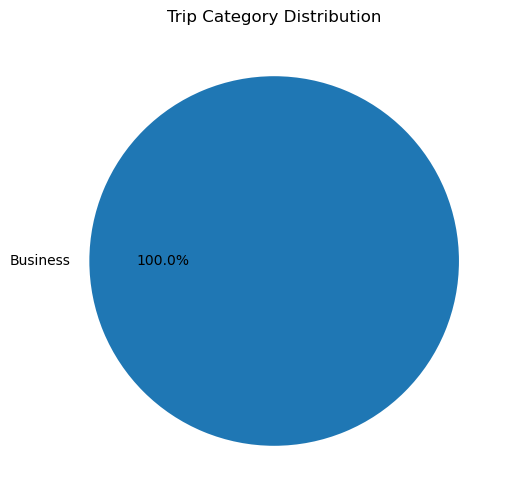

In [29]:
category = data['CATEGORY'].value_counts()

plt.figure(figsize=(6,6))

category.plot(kind='pie', autopct='%1.1f%%')

plt.title("Trip Category Distribution")

plt.ylabel('')

plt.show()

In [30]:
data['Month'] = data['START_DATE'].dt.month_name()

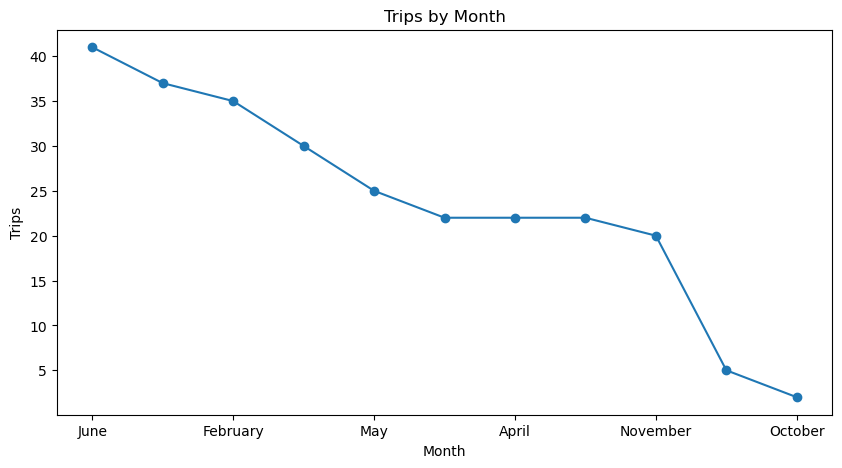

In [31]:
month_counts = data['Month'].value_counts()

plt.figure(figsize=(10,5))

month_counts.plot(kind='line', marker='o')

plt.title("Trips by Month")

plt.xlabel("Month")
plt.ylabel("Trips")

plt.show()

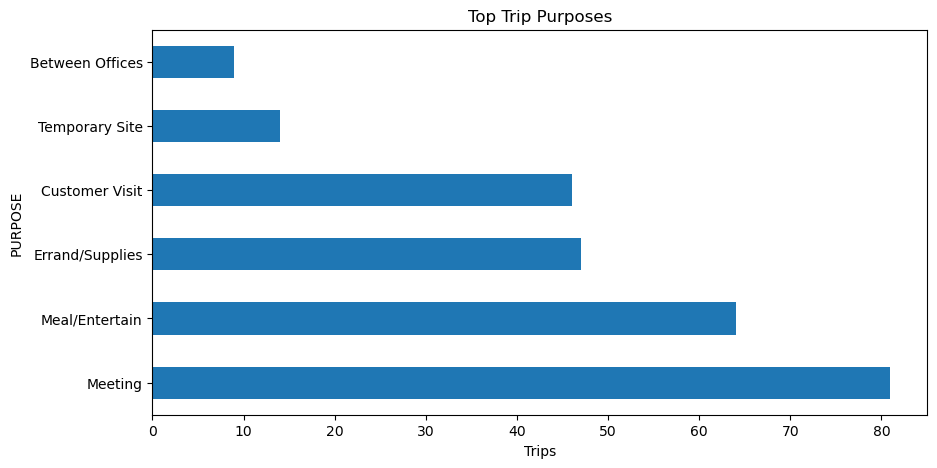

In [32]:
purpose = data['PURPOSE'].value_counts().head(10)

plt.figure(figsize=(10,5))

purpose.plot(kind='barh')

plt.title("Top Trip Purposes")

plt.xlabel("Trips")

plt.show()